## Задача 1: Классификация изображений футбольных логотипов с использованием трансферного обучения

### Шаг 1: Описание задачи

Возьмем предобученную на большом наборе данных (ImageNet) модель ResNet50, "заморозим" большую часть ее весов и заменим последний классификационный слой, чтобы адаптировать модель под наш специфический набор классов лого футбольных клубов.

Это позволяет быстро достичь хороших результатов даже при ограниченном объеме специфических данных, так как модель уже научилась извлекать полезные признаки из изображений на предыдущем этапе обучения.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time
import os
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
from PIL import Image
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split

### Шаг 2: Загрузка и подготовка данных

Для этой задачи мы будем использовать набор данных 'LaLiga Team Logos Dataset for CNN' с Kaggle.

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gorororororo23/laliga-team-logos-dataset-for-cnn")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/laliga-team-logos-dataset-for-cnn


In [35]:
data_dir = '/root/.cache/kagglehub/datasets/gorororororo23/laliga-team-logos-dataset-for-cnn/versions/1'

In [36]:
image_datasets = datasets.ImageFolder(data_dir)

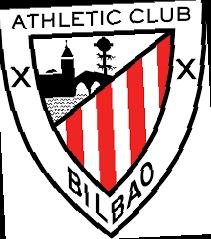

In [37]:
image_datasets[0][0]

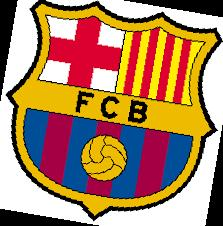

In [38]:
image_datasets[200][0]

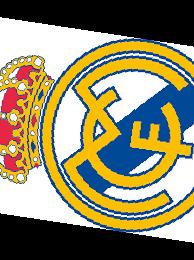

In [39]:
image_datasets[1400][0]

In [40]:
data_dir = os.path.join(data_dir, os.listdir(data_dir)[0])

In [41]:
def create_df(path):
    dd = {"images": [], "labels": []}

    for i in os.listdir(path):
        img_dir = os.path.join(path, i)
        for j in os.listdir(img_dir):
            dd["images"] += [os.path.join(img_dir, j)]
            dd["labels"] += [i]


    return pd.DataFrame(dd)


df = create_df(data_dir)

In [42]:
df

,images,labels
0,/root/.cache/kagglehub/datasets/gorororororo23...,Osasuna
1,/root/.cache/kagglehub/datasets/gorororororo23...,Osasuna
2,/root/.cache/kagglehub/datasets/gorororororo23...,Osasuna
3,/root/.cache/kagglehub/datasets/gorororororo23...,Osasuna
4,/root/.cache/kagglehub/datasets/gorororororo23...,Osasuna
...,...,...
1995,/root/.cache/kagglehub/datasets/gorororororo23...,Villarreal
1996,/root/.cache/kagglehub/datasets/gorororororo23...,Villarreal
1997,/root/.cache/kagglehub/datasets/gorororororo23...,Villarreal
1998,/root/.cache/kagglehub/datasets/gorororororo23...,Villarreal


In [49]:
index_label = dict()
label_index = dict()

for i, j in enumerate(df["labels"].unique()):
    index_label[i] = j
    label_index[j] = i

df["labels"] = df["labels"].map(label_index)

In [50]:
df

,images,labels
0,/root/.cache/kagglehub/datasets/gorororororo23...,0
1,/root/.cache/kagglehub/datasets/gorororororo23...,0
2,/root/.cache/kagglehub/datasets/gorororororo23...,0
3,/root/.cache/kagglehub/datasets/gorororororo23...,0
4,/root/.cache/kagglehub/datasets/gorororororo23...,0
...,...,...
1995,/root/.cache/kagglehub/datasets/gorororororo23...,19
1996,/root/.cache/kagglehub/datasets/gorororororo23...,19
1997,/root/.cache/kagglehub/datasets/gorororororo23...,19
1998,/root/.cache/kagglehub/datasets/gorororororo23...,19


In [43]:
STEP = 8
LR = 0.1
GAMMA = 0.1
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = df["labels"].nunique()

In [53]:
class Pipeline(Dataset):
    def __init__(self, data, transform):
        super(Pipeline, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):

        img, label = self.data[x, 0], self.data[x, 1]

        img = Image.open(img).convert("RGB")
        img = np.array(img)

        img = self.transform(img)
        return img, label

transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

train, val = train_test_split(df.values, random_state=42, test_size=0.2)
val, test = train_test_split(val, random_state=42, test_size=0.5)

train_ds = Pipeline(train, transform)
val_ds = Pipeline(val, transform)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

### Шаг 3: Описание модели

In [14]:
class ResNet(nn.Module):
    def __init__(self, model):
        super(ResNet, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResNet(resnet)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


### Шаг 4: Обучение модели

In [76]:
from tqdm import tqdm
import torchvision

# Функция для обучения модели
def train_model(model, criterion, optimizer, epochs=3):
    since = time.time()
    best_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        # Фаза обучения
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in tqdm(train_dl):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Фаза валидации
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in tqdm(val_dl):
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.set_grad_enabled(False):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        val_losses.append(epoch_loss)
        val_accs.append(epoch_acc)

        print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {max(val_accs):.4f}')

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'time_elapsed': time_elapsed
    }

resnet_model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
# Замораживаем все веса, кроме последнего слоя (transfer learning)
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 20)
# размораживаем наш классификатор
for param in resnet_model.fc.parameters():
    param.requires_grad = True
resnet_model = resnet_model.to(device)

print("\nTraining ResNet...")
criterion = nn.CrossEntropyLoss()
# Оптимизатор: обучаем только параметры последнего слоя, у которых requires_grad=True
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.01)
resnet_stats = train_model(resnet_model, criterion, optimizer)


Training ResNet...
Epoch 1/3
----------


100%|██████████| 100/100 [06:20<00:00,  3.80s/it]


Train Loss: 1.1070 Acc: 0.8638


100%|██████████| 13/13 [00:39<00:00,  3.03s/it]


Val Loss: 0.0005 Acc: 1.0000

Epoch 2/3
----------


...

Val Loss: 0.0001 Acc: 1.0000

Epoch 3/3
----------


100%|██████████| 100/100 [06:11<00:00,  3.72s/it]


Train Loss: 0.0003 Acc: 1.0000


100%|██████████| 13/13 [00:39<00:00,  3.02s/it]

Val Loss: 0.0001 Acc: 1.0000

Training complete in 20m 44s
Best val Acc: 1.0000


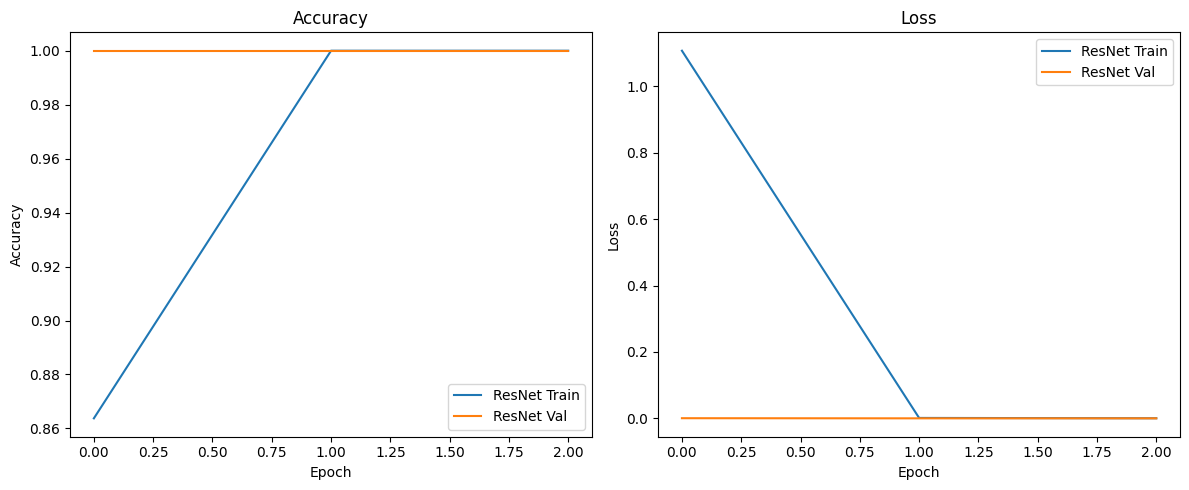

In [83]:
# Визуализация результатов
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Точность
plt.subplot(1, 2, 1)
plt.plot([a.cpu().numpy() for a in resnet_stats['train_accs']], label='ResNet Train')
plt.plot([a.cpu().numpy() for a in resnet_stats['val_accs']], label='ResNet Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Потери
plt.subplot(1, 2, 2)
plt.plot(resnet_stats['train_losses'], label='ResNet Train')
plt.plot(resnet_stats['val_losses'], label='ResNet Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Шаг 5: Визуализация результатов (результаты идеальные, за 3 эпохи предобученный резнет легко доучил логотипы футбольных клубов)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00         9
           8       1.00      1.00      1.00         6
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00         9
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00        14
          15       1.00      1.00      1.00        12
          16       1.00      1.00      1.00        15
          17       1.00    

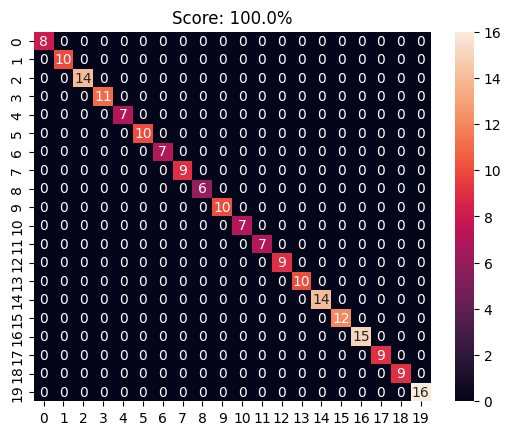

In [79]:
best_model = resnet_model

def predict(img):
    img = Image.open(img).convert("RGB")
    img = transform(np.array(img))
    img = img.view([1, 3, 224, 224])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()
        out = best_model(img)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)


truth = []
preds = []
probas = []

for i in range(test.shape[0]):
    truth += [test[i, 1]]
    pred, proba = predict(test[i, 0])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()

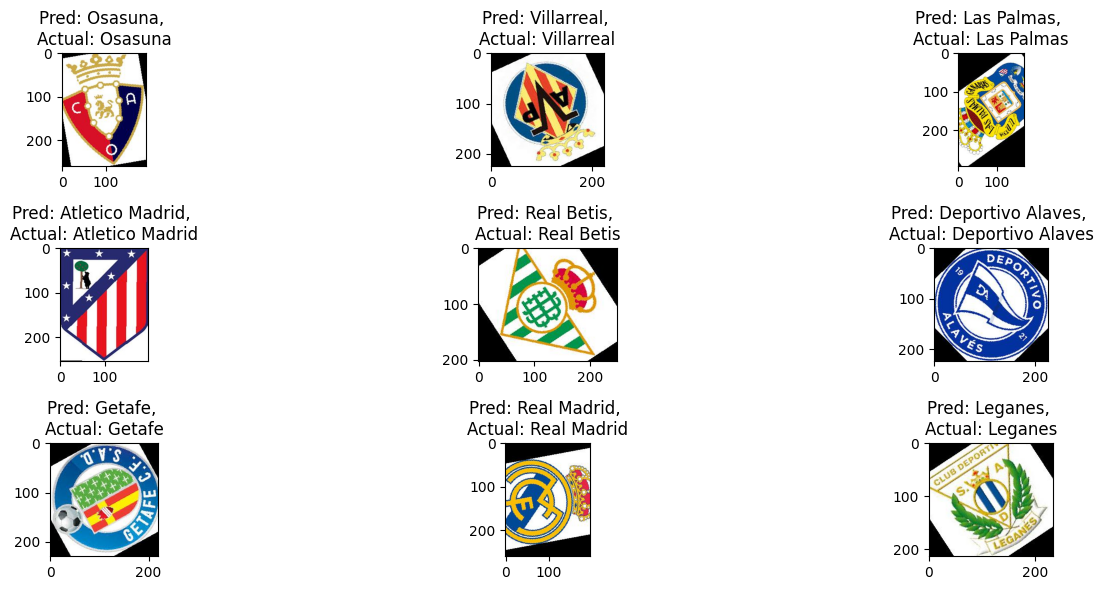

In [82]:
index = 0

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 6))

for i in range(3):
    for j in range(3):
        axes[i][j].imshow(np.array(Image.open(test[index, 0]).convert("RGB")))
        axes[i][j].set_title("Pred: {}, \nActual: {}".format(index_label[preds[index]], index_label[truth[index]]))
        index += 1

plt.tight_layout()
plt.show()

## Задача 2: Обнаружение объектов (на футбольном поле) с использованием YOLOv8

### Шаг 1: Описание задачи

В этой задаче мы научим модель обнаружения объектов YOLOv8 распознавать футболистов на изображениях. YOLO (You Only Look Once) - это семейство моделей, известных своей высокой скоростью и точностью в задачах обнаружения объектов. Мы возьмем предобученную на COCO датасете модель YOLOv8 и дообучим ее (fine-tuning) на специфическом наборе данных, содержащем изображения на футбольном поле с аннотациями - ограничивающими рамками.

Мы будем использовать библиотеку `ultralytics`, которая предоставляет удобный интерфейс для работы с моделями YOLOv8.

In [ ]:
!pip install ultralytics

from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

### Шаг 2: Подготовка данных

Мы будем использовать набор данных с платформы Kaggle. Набор данных включает 312 изображений, аннотируются в формате YOLOv8. Существует 4 класса. Это мяч, вратарь, игрок и судья.

**Ссылка на набор данных:** `https://www.kaggle.com/datasets/borhanitrash/football-players-detection-dataset/data`


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("borhanitrash/football-players-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 68.0M/68.0M [00:03<00:00, 23.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1


In [ ]:
dataset_path = '/root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1'
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

print(f"Предполагаемый путь к файлу data.yaml: {data_yaml_path}")

# Проверка наличия файла data.yaml (опционально)
if os.path.exists(data_yaml_path):
    print("Файл data.yaml найден. Данные готовы к использованию.")
else:
    print("Файл data.yaml НЕ найден. Пожалуйста, скачайте данные с Roboflow, следуя инструкциям.")

Предполагаемый путь к файлу data.yaml: /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/data.yaml
Файл data.yaml найден. Данные готовы к использованию.


In [ ]:
# Загрузка предобученной модели YOLOv8 (например, yolov8n.pt - наименьшая и быстрая)
model = YOLO('yolov8n.pt')

# Запуск обучения
# 'data' указывает путь к файлу data.yaml вашего набора данных
# 'epochs' - количество эпох обучения (для демонстрации достаточно небольшого числа)
# 'imgsz' - размер изображений (рекомендуется 640)
# 'device' - устройство для обучения ('0' для GPU, 'cpu' для CPU)

print(f"Начало дообучения модели YOLOv8 на датасете {dataset_path}...")

results = model.train(
    data=data_yaml_path,  # Путь к файлу data.yaml
    epochs=25,            # Количество эпох (можно увеличить для лучшего результата)
    imgsz=640,            # Размер изображения для обучения
    device=0 if torch.cuda.is_available() else 'cpu' # Использование GPU, если доступно
)

print("Дообучение модели завершено. Результаты сохранены в runs/detect/trainX")

100%|██████████| 6.25M/6.25M [00:00<00:00, 17.9MB/s]


Начало дообучения модели YOLOv8 на датасете /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1...
Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

100%|██████████| 755k/755k [00:00<00:00, 3.63MB/s]

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1     37248  ultralytics.nn.modules.block.C2f             [192, 64, 1]                  
 16                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    123648  ultralytics.nn.modules.block.C2f             [192, 128, 1]                 
 19                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128,

...

      25/25         0G      1.106     0.7467     0.8073        231        640: 100%|██████████| 16/16 [02:23<00:00,  8.95s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<00:00,  2.77s/it]

                   all         43       1025      0.771      0.505      0.558      0.346

25 epochs completed in 1.102 hours.


Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (AMD EPYC 7B12)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<00:00,  2.77s/it]


                   all         43       1025       0.77      0.505      0.558      0.345
                  ball         39         39          1          0     0.0255    0.00255
            goalkeeper         32         32      0.736      0.688      0.798      0.488
                player         43        853       0.82      0.946      0.944       0.62
               referee         43        101      0.526      0.386      0.467       0.27
Speed: 1.4ms preprocess, 104.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/train
Дообучение модели завершено. Результаты сохранены в runs/detect/trainX


### Шаг 3: Оценка модели и визуализация предсказаний

После завершения обучения важно оценить производительность дообученной модели на отдельной валидационной выборке. YOLOv8 автоматически рассчитывает и сохраняет различные метрики в процессе обучения, но мы можем явно запустить валидацию после обучения, чтобы получить итоговые метрики, такие как mAP (mean Average Precision).

mAP@0.5 - это средняя точность при пороге Intersection over Union (IoU) 0.5.
mAP@0.5:0.95 - это средняя точность по разным порогам IoU от 0.5 до 0.95.

In [ ]:
# Загрузка лучшей дообученной модели
# Путь к лучшей модели обычно находится в папке runs/detect/trainX/weights/best.pt
best_model_path = os.path.join('runs', 'detect', 'train', 'weights', 'best.pt')

if os.path.exists(best_model_path):
    print(f"Загрузка лучшей модели из {best_model_path}")
    model = YOLO(best_model_path)

    # Запуск валидации на тестовой выборке
    # Укажите путь к файлу data.yaml
    print("Запуск валидации модели...")
    metrics = model.val(data=data_yaml_path) # Валидация на тестовой выборке

    print("Метрики валидации:")
    print(f"mAP@0.5: {metrics.box.map50}")
    print(f"mAP@0.5:0.95: {metrics.box.map}")

    # Запуск предсказаний на нескольких тестовых изображениях
    # YOLO сохранит результаты с отрисованными рамками в папку runs/detect/predictX
    print("Запуск предсказаний на тестовых изображениях...")

    # Укажите путь к папке с тестовыми изображениями из вашего набора данных
    test_images_dir = os.path.join(dataset_path, 'test', 'images') # Путь к тестовым изображениям

    if os.path.exists(test_images_dir):
        # Получаем список первых нескольких тестовых изображений
        test_image_files = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5] # Берем первые 5 изображений

        if test_image_files:
            print("Запуск предсказаний на выбранных тестовых изображениях:")
            for img_path in test_image_files:
                print(f"  Обработка: {img_path}")
                results = model(img_path) # Запуск предсказания

            print("Предсказания сохранены в runs/detect/predictX. Визуализация...")

            # Отображение одного из изображений с предсказаниями
            # Результаты сохраняются в runs/detect/predictX
            # Найдем последнюю папку predict
            predict_dirs = sorted([d for d in os.listdir('runs/detect') if d.startswith('predict')])
            if predict_dirs:
                latest_predict_dir = os.path.join('runs', 'detect', predict_dirs[-1])
                predicted_images = [os.path.join(latest_predict_dir, f) for f in os.listdir(latest_predict_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

                if predicted_images:
                    print(f"Отображение первого изображения с предсказаниями из {latest_predict_dir}:")
                    img = mpimg.imread(predicted_images[0])
                    plt.figure(figsize=(10, 10))
                    plt.imshow(img)
                    plt.axis('off')
                    plt.show()
                else:
                    print("Не найдено изображений в папке предсказаний.")
            else:
                 print("Не найдено папок с результатами предсказаний (runs/detect/predictX).")

        else:
            print(f"Не найдено изображений в тестовой директории: {test_images_dir}")
    else:
        print(f"Директория тестовых изображений не найдена: {test_images_dir}. Убедитесь, что указан правильный путь и данные скачаны.")

else:
    print(f"Файл лучшей модели не найден по пути: {best_model_path}. Убедитесь, что обучение прошло успешно.")

Загрузка лучшей модели из runs/detect/train/weights/best.pt
Запуск валидации модели...
Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (AMD EPYC 7B12)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 1645.7±436.1 MB/s, size: 211.9 KB)


val: Scanning /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100%|██████████| 43/43 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:10<00:00,  3.66s/it]


                   all         43       1025       0.77      0.505      0.558      0.345
                  ball         39         39          1          0     0.0255    0.00255
            goalkeeper         32         32      0.736      0.688      0.798      0.488
                player         43        853       0.82      0.946      0.944       0.62
               referee         43        101      0.526      0.386      0.467       0.27
Speed: 2.7ms preprocess, 211.9ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to runs/detect/val
Метрики валидации:
mAP@0.5: 0.5584013753812018
mAP@0.5:0.95: 0.34504925128068126
Запуск предсказаний на тестовых изображениях...
Запуск предсказаний на выбранных тестовых изображениях:
  Обработка: /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/test/images/4b770a_5_1_png.rf.d19a0dd86c787e4bcc48c6ae618b1d79.jpg

image 1/1 /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection